In [1]:
#Imports and Loading Raw Data ExoTrain data, checking tha shape of the data
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pandas as pd
from scipy.signal import spectrogram
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import savgol_filter
from numpy.polynomial import Polynomial
from scipy.signal import find_peaks
train_data = np.loadtxt('exoTrain.csv', delimiter=',', skiprows=1)
print("Shape:", train_data.shape)
print(train_data[:5, :10])

Shape: (5087, 3198)
[[    2.      93.85    83.81    20.1    -26.98   -39.56  -124.71  -135.18
    -96.27   -79.89]
 [    2.     -38.88   -33.83   -58.54   -40.09   -79.31   -72.81   -86.55
    -85.33   -83.97]
 [    2.     532.64   535.92   513.73   496.92   456.45   466.     464.5
    486.39   436.56]
 [    2.     326.52   347.39   302.35   298.13   317.74   312.7    322.33
    311.31   312.42]
 [    2.   -1107.21 -1112.59 -1118.95 -1095.1  -1057.55 -1034.48  -998.34
  -1022.71  -989.57]]


In [2]:
#Assigning Data based on labels, grouping the Exoplanets
#Outputting the total number of exoplanets
labels = train_data[:, 0]
light_curves = train_data[:, 1:]
exoplanet_curves = light_curves[labels == 2]
print("# of exo:", exoplanet_curves.shape[0])
#Found Exos by number

# of exo: 37


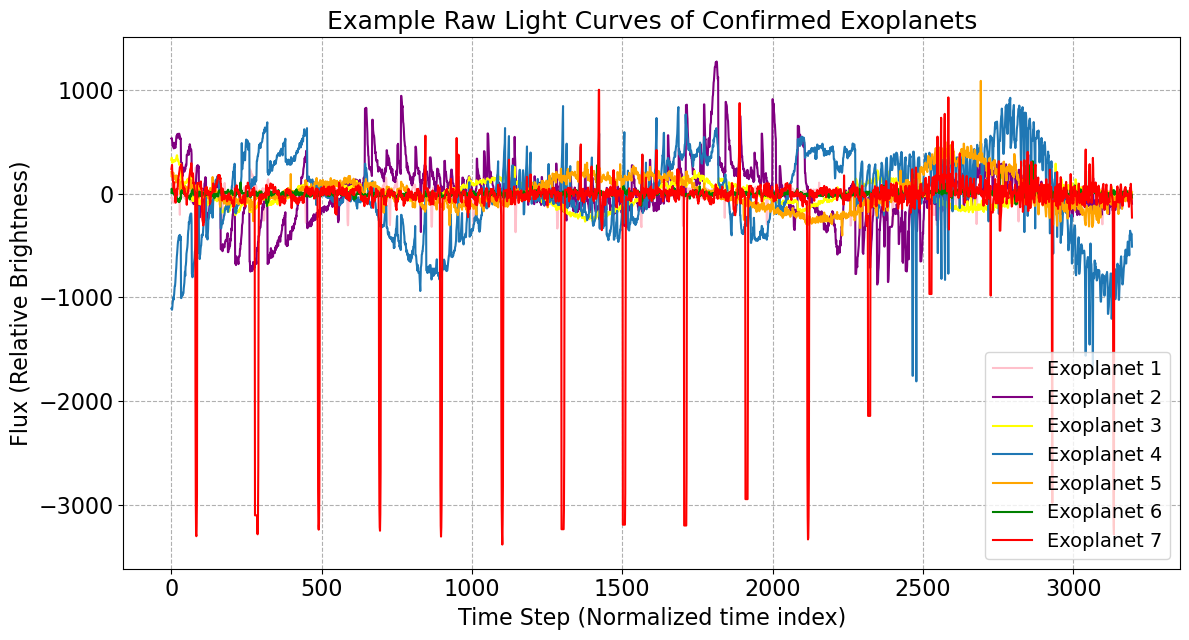

In [3]:
#Plotting raw Flux data of exoplanets for visuals, assigning colors
remap = [1, 2, 3, 4, 5, 6, 7]
colors = [ "pink", "purple", "yellow", 'tab:blue', "orange", "green","red"]
plt.figure(figsize=(12, 6.5))
for i in range(7):
    plt.plot(exoplanet_curves[remap[i]], label=f"Exoplanet {i+1}", color=colors[i])
plt.xlabel("Time Step (Normalized time index)", fontsize=16)
plt.ylabel("Flux (Relative Brightness)", fontsize=16)
plt.title("Example Raw Light Curves of Confirmed Exoplanets", fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()
#plotted exos for examintion, selected 4,5,6,7

In [4]:
# Check NaNs (All Data)
num_nans = np.isnan(exoplanet_curves).sum()
print("Number of NaN values:", num_nans)
#checked NaN

Number of NaN values: 0


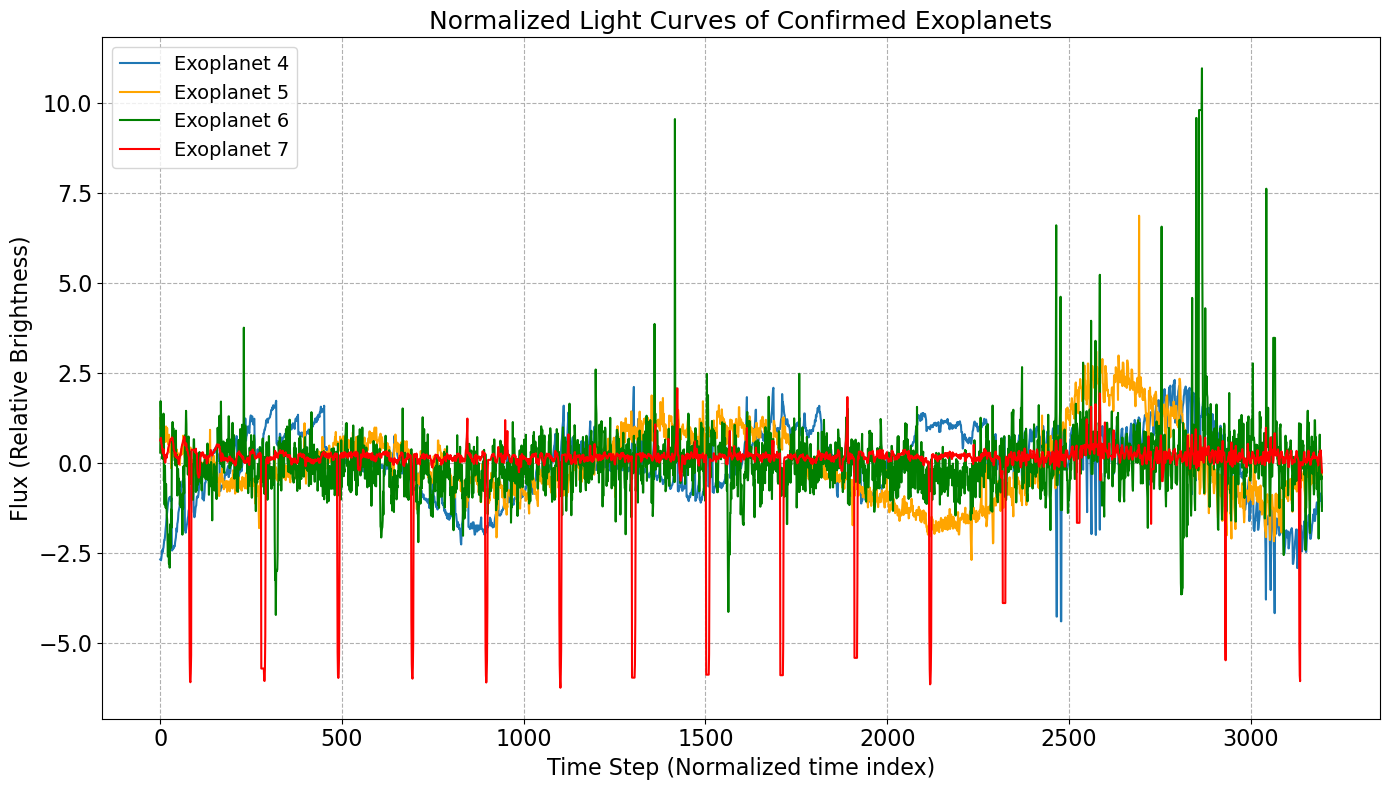

In [5]:
#Normalize and select/plot the Exoplanets we want to work with
#(Subtrack mean divided by std)
exoplanet_curves_normalized = (exoplanet_curves - np.mean(exoplanet_curves, axis=1, keepdims=True)) / np.std(exoplanet_curves, axis=1, keepdims=True)
selected_indices = [4, 5, 6, 7]
selected_curves = exoplanet_curves_normalized[selected_indices]
selected_labels = [f"Exoplanet {i}" for i in selected_indices]

plt.figure(figsize=(14, 8))
plt.plot(exoplanet_curves_normalized[4],color='tab:blue', label="Exoplanet 4")
plt.plot(exoplanet_curves_normalized[5],color='orange', label="Exoplanet 5")
plt.plot(exoplanet_curves_normalized[6],color='green', label="Exoplanet 6")
plt.plot(exoplanet_curves_normalized[7],color='red', label="Exoplanet 7")
plt.xlabel("Time Step (Normalized time index)",fontsize=16)
plt.ylabel("Flux (Relative Brightness)",fontsize=16)
plt.title("Normalized Light Curves of Confirmed Exoplanets",fontsize=18)
plt.legend(fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True,linestyle="--")
plt.tight_layout()
plt.show()
#Normalized the selected exos

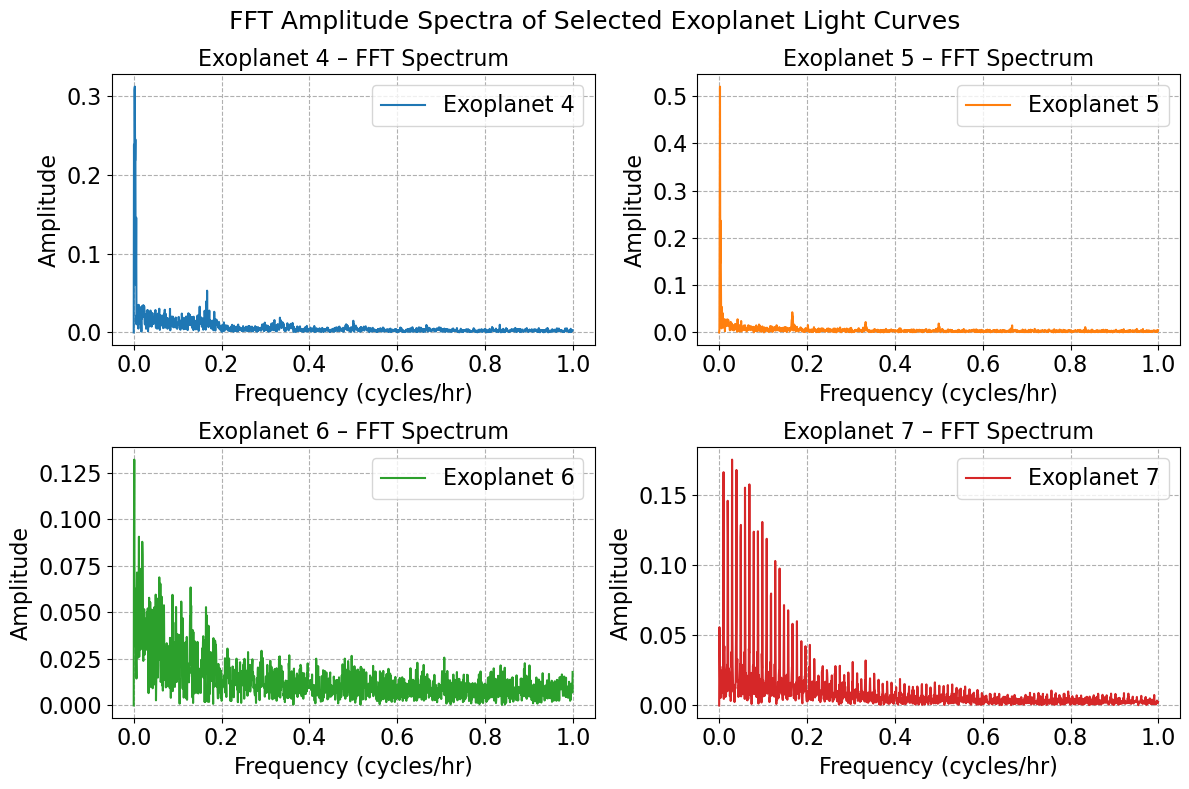

In [6]:
#Attemping Fast Fourier Transforms, plotting data in frequncy domain using fft
#Outputting a four figure plot that contains all four Fouier analysis
selected_indices = [4, 5, 6, 7]
labels = [f"Exoplanet {i}" for i in selected_indices]
N = exoplanet_curves_normalized.shape[1]
dt = 0.5
freq = fftfreq(N, d=dt)
freq = freq[:N//2]
amplitudes = [np.abs(fft(exoplanet_curves_normalized[i]))[:N//2] / N for i in selected_indices]
max_amp = max(np.max(a) for a in amplitudes)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), tight_layout=True)
axes[0,0].plot(freq, amplitudes[0], label=labels[0], color='tab:blue')
axes[0,0].set_title(f"{labels[0]} – FFT Spectrum",fontsize=16)
axes[0,0].set_xlabel("Frequency (cycles/hr)",fontsize=16)
axes[0,0].set_ylabel("Amplitude",fontsize=16)
axes[0,0].grid(True, linestyle='--')
axes[0,0].legend(fontsize=16)
axes[0,0].tick_params(axis='both', labelsize=16)

axes[0,1].plot(freq, amplitudes[1], label=labels[1], color='tab:orange')
axes[0,1].set_title(f"{labels[1]} – FFT Spectrum",fontsize=16)
axes[0,1].set_xlabel("Frequency (cycles/hr)",fontsize=16)
axes[0,1].set_ylabel("Amplitude",fontsize=16)
axes[0,1].grid(True, linestyle='--')
axes[0,1].legend(fontsize=16)
axes[0,1].tick_params(axis='both',labelsize=16)

axes[1,0].plot(freq, amplitudes[2], label=labels[2], color='tab:green')
axes[1,0].set_title(f"{labels[2]} – FFT Spectrum",fontsize=16)
axes[1,0].set_xlabel("Frequency (cycles/hr)",fontsize=16)
axes[1,0].set_ylabel("Amplitude",fontsize=16)
axes[1,0].grid(True, linestyle='--')
axes[1,0].legend(fontsize=16)
axes[1,0].tick_params(axis='both', labelsize=16)

axes[1,1].plot(freq, amplitudes[3], label=labels[3], color='tab:red')
axes[1,1].set_title(f"{labels[3]} – FFT Spectrum",fontsize=16)
axes[1,1].set_xlabel("Frequency (cycles/hr)",fontsize=16)
axes[1,1].set_ylabel("Amplitude",fontsize=16)
axes[1,1].grid(True, linestyle='--')
axes[1,1].legend(fontsize=16)
axes[1,1].tick_params(axis='both', labelsize=16)

plt.suptitle("FFT Amplitude Spectra of Selected Exoplanet Light Curves", fontsize=18)
plt.show()
#Plotted FFTs

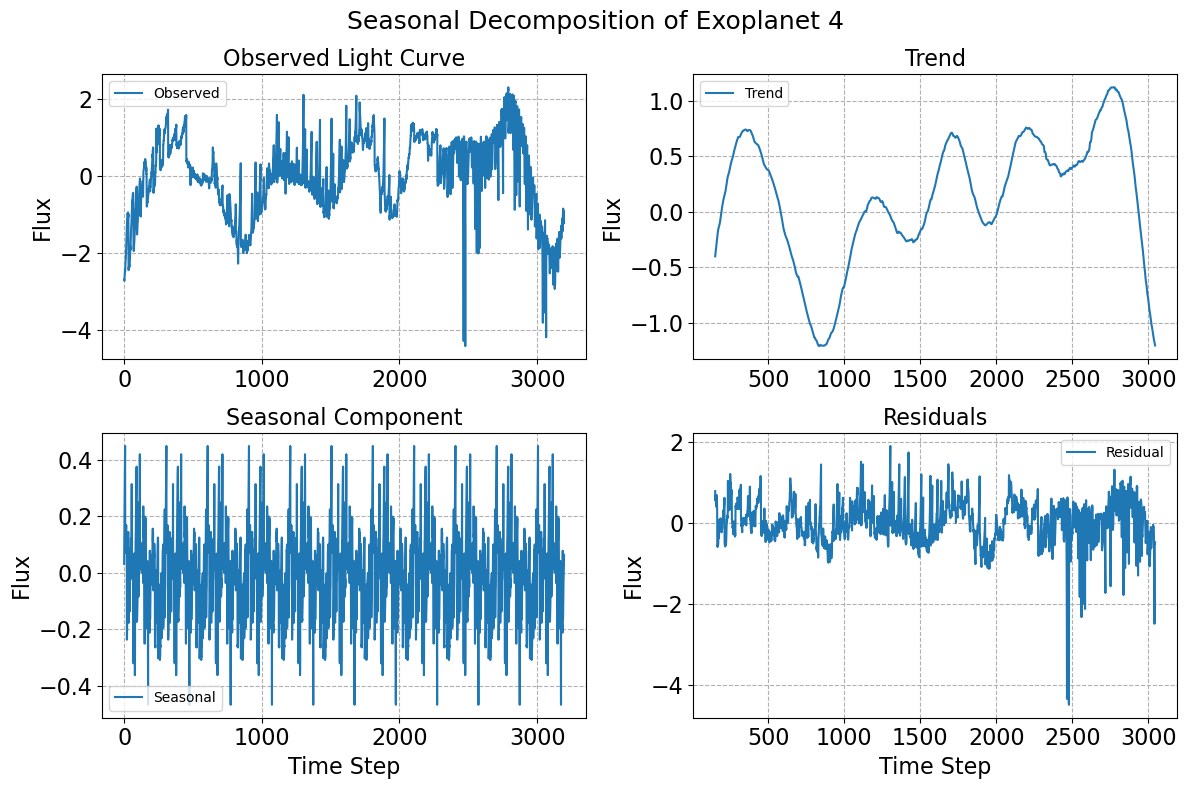

In [7]:
#Exo 4
#Applying seasonal decomposition, outputting a four figure plot,
#of Observed, trend, seasonal component, and residuals
exo4 = exoplanet_curves_normalized[4]
exo4_series = pd.Series(exo4)
decomp4 = seasonal_decompose(exo4_series, model='additive', period=300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), tight_layout=True)
axes[0,0].plot(decomp4.observed, label='Observed', color='tab:blue')
axes[0,0].set_title('Observed Light Curve', fontsize=16)
axes[0,0].set_ylabel('Flux', fontsize=16)
axes[0,0].legend()
axes[0,0].tick_params(axis='both', labelsize=16)
axes[0,0].grid(True, linestyle='--')

axes[0,1].plot(decomp4.trend, label='Trend', color='tab:blue')
axes[0,1].set_title('Trend', fontsize=16)
axes[0,1].set_ylabel('Flux', fontsize=16)
axes[0,1].legend()
axes[0,1].tick_params(axis='both', labelsize=16)
axes[0,1].grid(True, linestyle='--')

axes[1,0].plot(decomp4.seasonal, label='Seasonal', color='tab:blue')
axes[1,0].set_title('Seasonal Component', fontsize=16)
axes[1,0].set_ylabel('Flux', fontsize=16)
axes[1,0].set_xlabel('Time Step', fontsize=16)
axes[1,0].legend()
axes[1,0].tick_params(axis='both', labelsize=16)
axes[1,0].grid(True, linestyle='--')

axes[1,1].plot(decomp4.resid, label='Residual', color='tab:blue')
axes[1,1].set_title('Residuals', fontsize=16)
axes[1,1].set_ylabel('Flux', fontsize=16)
axes[1,1].set_xlabel('Time Step', fontsize=16)
axes[1,1].legend()
axes[1,1].tick_params(axis='both', labelsize=16)
axes[1,1].grid(True, linestyle='--')

plt.suptitle('Seasonal Decomposition of Exoplanet 4', fontsize=18)
plt.show()


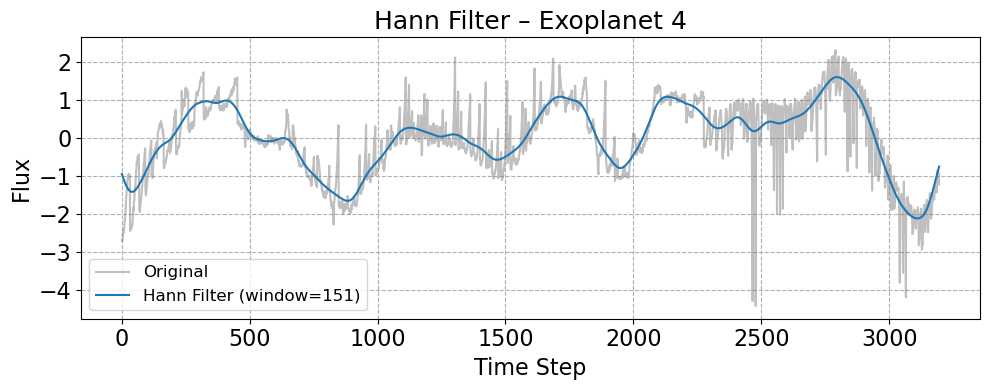

In [8]:
#Hann Filter concolved to find a trend, and plotting it over the observed curve
window_size = 151
hann_kernel = np.hanning(window_size)
hann_kernel /= np.sum(hann_kernel)
exo4_hann = np.convolve(exo4_series, hann_kernel, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(exo4_series, label="Original", color="grey", alpha=0.5)
plt.plot(exo4_hann, label=f"Hann Filter (window={window_size})", color="tab:blue")
plt.title("Hann Filter – Exoplanet 4", fontsize=18)
plt.xlabel("Time Step", fontsize=16)
plt.ylabel("Flux", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

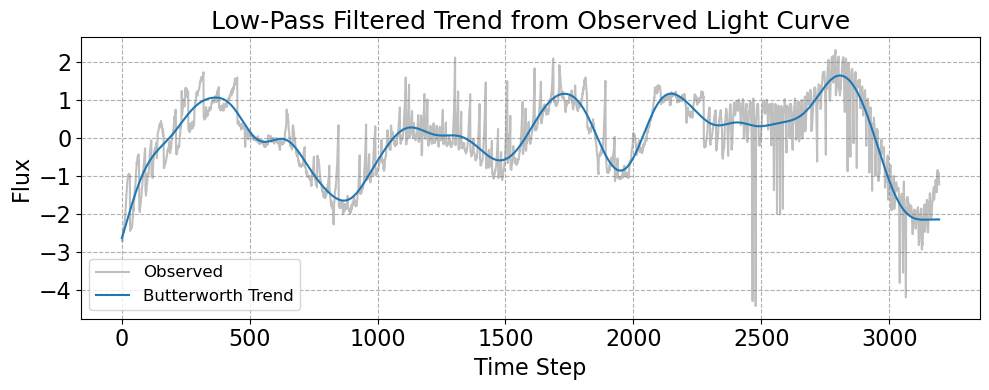

In [9]:
#Applying a Low_Pass filter(butterworth), to find a trend
from scipy.signal import butter, filtfilt
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

exo4_clean = exo4_series.dropna()
fs = 1 / dt
cutoff = 0.01
trend_filtered = butter_lowpass_filter(decomp4.observed.dropna(), cutoff, fs)

plt.figure(figsize=(10, 4))
plt.plot(decomp4.observed, label="Observed",color="grey", alpha=0.5)
plt.plot(decomp4.observed.dropna().index, trend_filtered, label="Butterworth Trend", color="tab:blue")
plt.title("Low-Pass Filtered Trend from Observed Light Curve", fontsize=18)
plt.xlabel("Time Step", fontsize=16)
plt.ylabel("Flux", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize = 12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

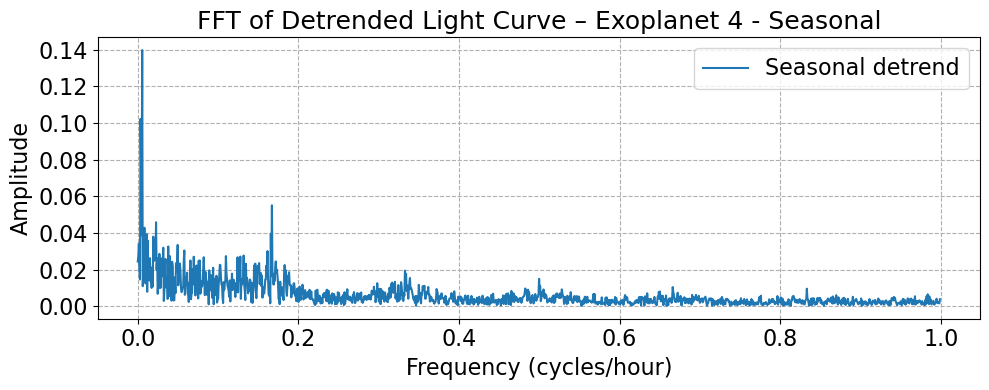

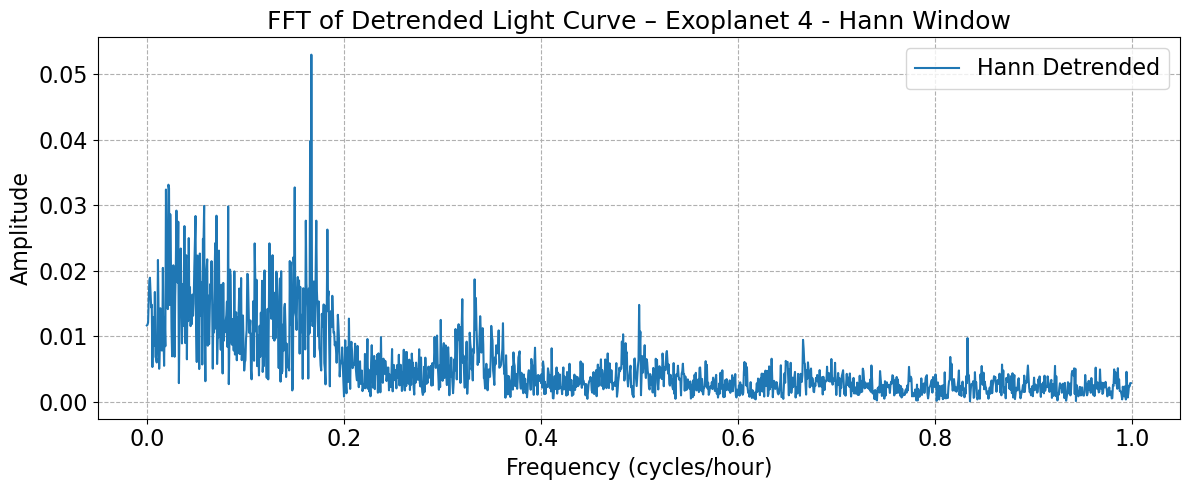

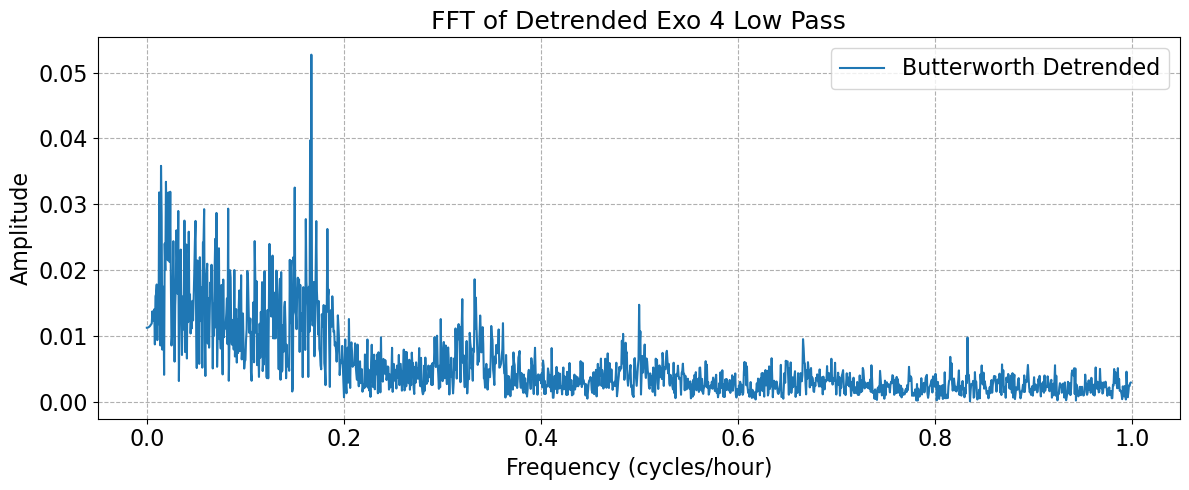

In [10]:
#Detrend FFTs  from the seasonal component, hann window, and low pass filter.
#For examiniation
detrended_exo4 = decomp4.observed - decomp4.trend
detrended_exo4_clean = detrended_exo4.dropna()
N4 = len(detrended_exo4_clean)
dt = 0.5 
freq4 = fftfreq(N4, d=dt)
fft_vals4 = np.abs(fft(detrended_exo4_clean))[:N4//2] / N4

plt.figure(figsize=(10, 4))
plt.plot(freq4[:N4//2], fft_vals4, color='tab:blue',label='Seasonal detrend')
plt.title("FFT of Detrended Light Curve – Exoplanet 4 - Seasonal",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Hann Window
hann_trend = np.convolve(exo4_clean, hann_kernel, mode='same')
detrended_hann = exo4_clean - hann_trend
N = len(exo4_clean)
freq = fftfreq(N, d=dt)
fft_hann = np.abs(fft(detrended_hann))[:N//2] / N
plt.figure(figsize=(12, 5))
plt.plot(freq[:N//2], fft_hann, label="Hann Detrended", color="tab:blue")
plt.title("FFT of Detrended Light Curve – Exoplanet 4 - Hann Window",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Low_Pass
detrended_butter = exo4_clean - trend_filtered
fft_butter = np.abs(fft(detrended_butter))[:N//2] / N
plt.figure(figsize=(12, 5))
plt.plot(freq[:N//2], fft_butter, label="Butterworth Detrended", color="tab:blue")
plt.title("FFT of Detrended Exo 4 Low Pass",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

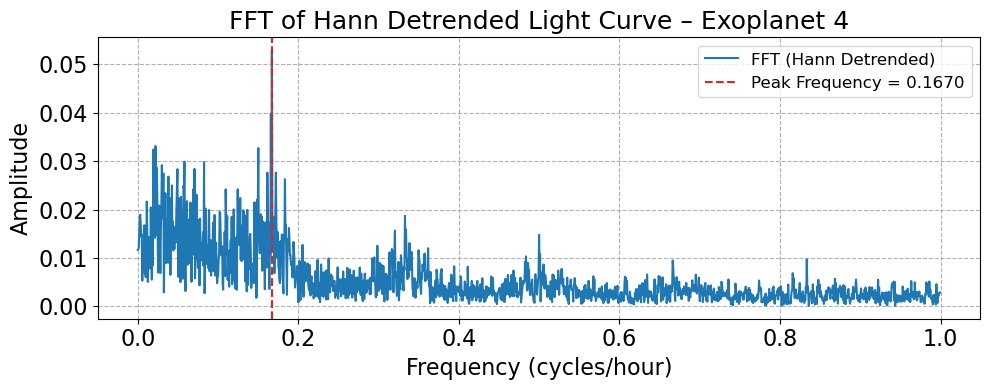

 Estimated Transit Period: 5.99 hours


In [11]:
#Attempt in estimating the period from the Hann window filtered FFT,
#By taking the inverse of domiant frquencies
peak_idx = np.argmax(fft_hann[1:]) + 1
freq_pos = freq[:N//2]
peak_freq = freq_pos[peak_idx]
estimated_period_hours = 1 / peak_freq if peak_freq > 0 else np.nan

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, fft_hann, label="FFT (Hann Detrended)", color='tab:blue')
plt.axvline(peak_freq, color='tab:red', linestyle='--', label=f"Peak Frequency = {peak_freq:.4f}")
plt.title("FFT of Hann Detrended Light Curve – Exoplanet 4",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()
print(f" Estimated Transit Period: {estimated_period_hours:.2f} hours")

Estimated Transit Period: 24.98 hours


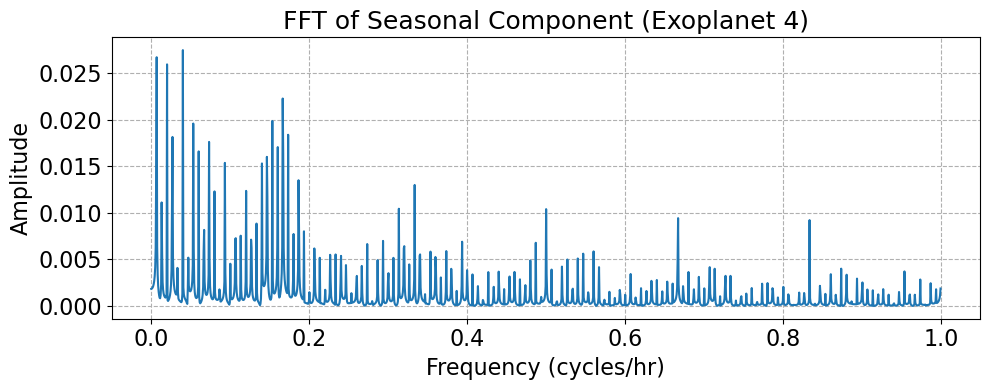

In [12]:
#Estimate Transit Period from Seasonal Component
#Outputting another estimated transit period
seasonal = decomp4.seasonal
seasonal_fft = np.abs(fft(seasonal))[:N//2] / N
peak_freq_idx = np.argmax(seasonal_fft[1:]) + 1
peak_freq = freq[peak_freq_idx]
estimated_period_hours = 1 / peak_freq if peak_freq != 0 else np.nan
print(f"Estimated Transit Period: {estimated_period_hours:.2f} hours")

plt.figure(figsize=(10, 4))
plt.plot(freq[:N//2], seasonal_fft, color='tab:blue')
plt.title("FFT of Seasonal Component (Exoplanet 4)",fontsize=18)
plt.xlabel("Frequency (cycles/hr)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

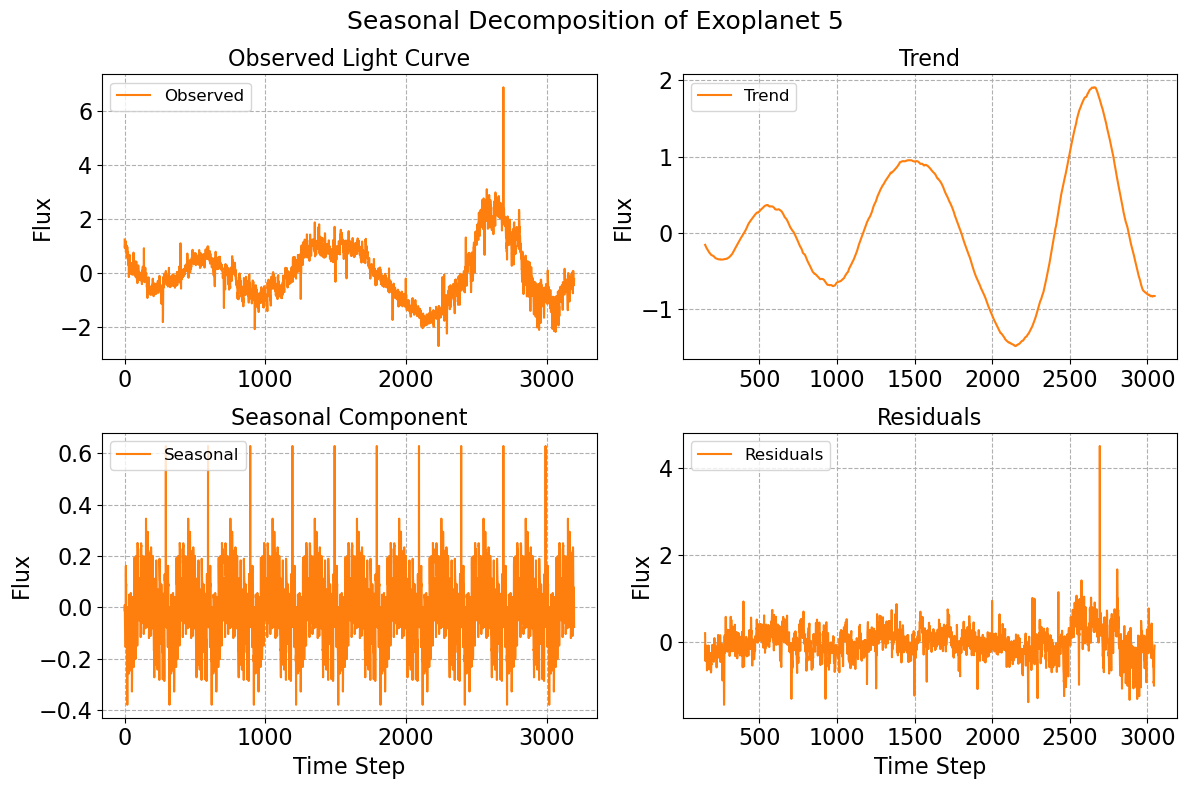

In [13]:
#Exo 5 
#Seasonal decomp of the data, outputting the same 4 figure plot
exo5 = exoplanet_curves_normalized[5]
exo5_series = pd.Series(exo5)
decomp5 = seasonal_decompose(exo5_series, model='additive', period=300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), tight_layout=True)

axes[0,0].plot(decomp5.observed, label='Observed', color='tab:orange')
axes[0,0].set_title('Observed Light Curve', fontsize=16)
axes[0,0].set_ylabel('Flux', fontsize=16)
axes[0,0].legend(fontsize=12)
axes[0,0].tick_params(axis='both', labelsize=16)
axes[0,0].grid(True, linestyle='--')

axes[0,1].plot(decomp5.trend, label='Trend', color='tab:orange')
axes[0,1].set_title('Trend', fontsize=16)
axes[0,1].set_ylabel('Flux', fontsize=16)
axes[0,1].legend(fontsize=12)
axes[0,1].tick_params(axis='both', labelsize=16)
axes[0,1].grid(True, linestyle='--')

axes[1,0].plot(decomp5.seasonal, label='Seasonal', color='tab:orange')
axes[1,0].set_title('Seasonal Component', fontsize=16)
axes[1,0].set_ylabel('Flux', fontsize=16)
axes[1,0].set_xlabel('Time Step', fontsize=16)
axes[1,0].legend( fontsize=12)
axes[1,0].tick_params(axis='both', labelsize=16)
axes[1,0].grid(True, linestyle='--')

axes[1,1].plot(decomp5.resid, label='Residuals', color='tab:orange')
axes[1,1].set_title('Residuals', fontsize=16)
axes[1,1].set_ylabel('Flux', fontsize=16)
axes[1,1].set_xlabel('Time Step', fontsize=16)
axes[1,1].legend(fontsize=12)
axes[1,1].tick_params(axis='both', labelsize=16)
axes[1,1].grid(True, linestyle='--')

plt.suptitle('Seasonal Decomposition of Exoplanet 5', fontsize=18)
plt.show()

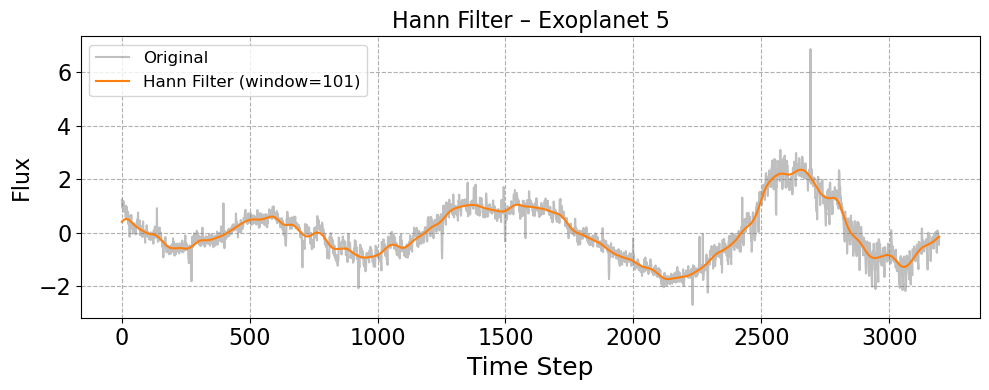

In [14]:
#Again applying a Hann window to find trend
window_size = 101
hann_kernel = np.hanning(window_size)
hann_kernel /= np.sum(hann_kernel)
exo5_hann = np.convolve(exo5_series, hann_kernel, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(exo5_series, label="Original", color="grey", alpha=0.5)
plt.plot(exo5_hann, label=f"Hann Filter (window={window_size})", color="tab:orange")
plt.title("Hann Filter – Exoplanet 5",fontsize=16)
plt.xlabel("Time Step",fontsize=18)
plt.ylabel("Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

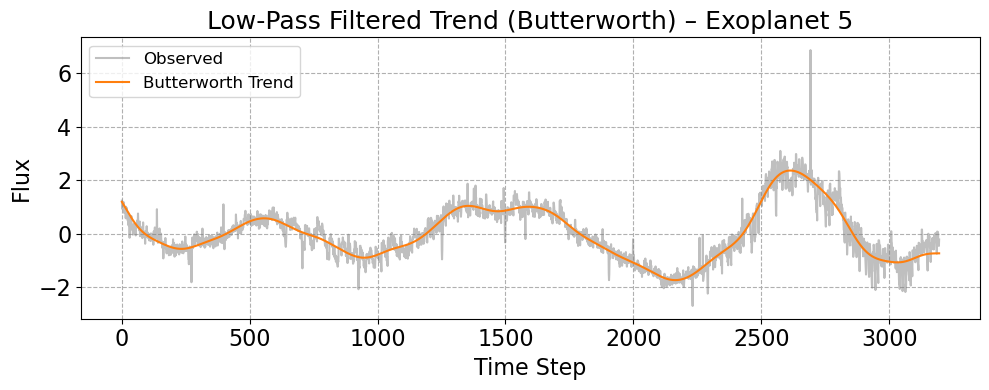

In [15]:
#again applying the Butterworth Low_pass filter
exo5_clean = exo5_series.dropna()
fs = 1 / dt
cutoff = 0.01 
trend_butter = butter_lowpass_filter(exo5_clean.values, cutoff=cutoff, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(exo5_clean.index, exo5_clean, color='grey', label="Observed", alpha=0.5)
plt.plot(exo5_clean.index, trend_butter, label="Butterworth Trend", color='tab:orange')
plt.title("Low-Pass Filtered Trend (Butterworth) – Exoplanet 5",fontsize=18)
plt.xlabel("Time Step",fontsize=16)
plt.ylabel("Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

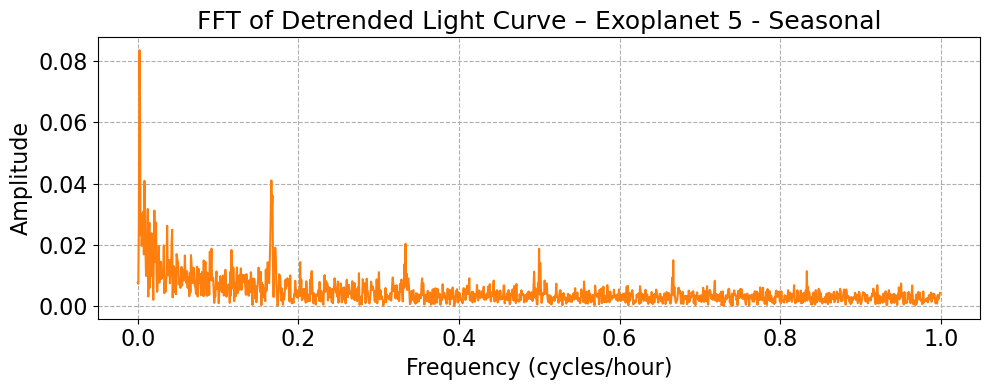

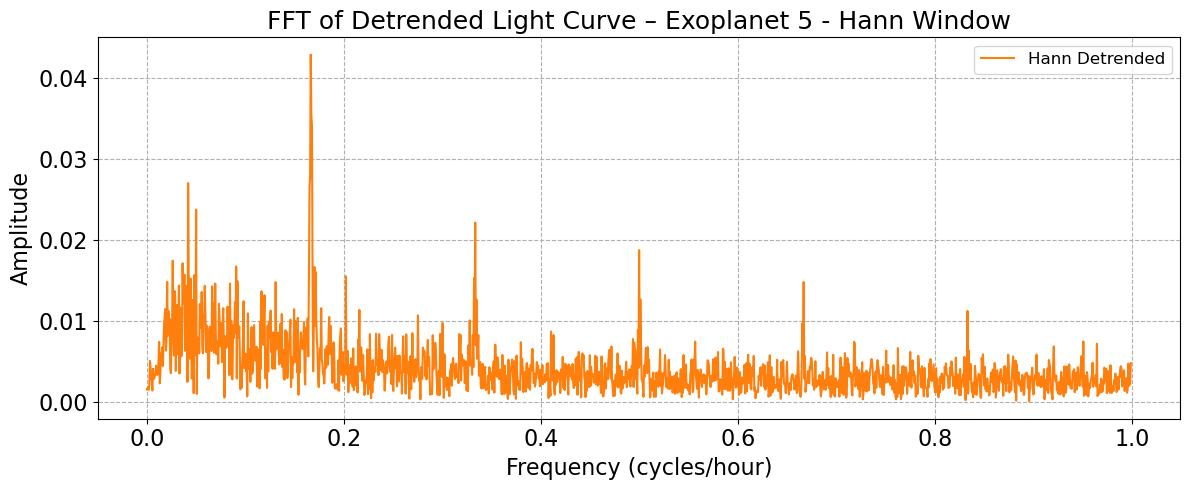

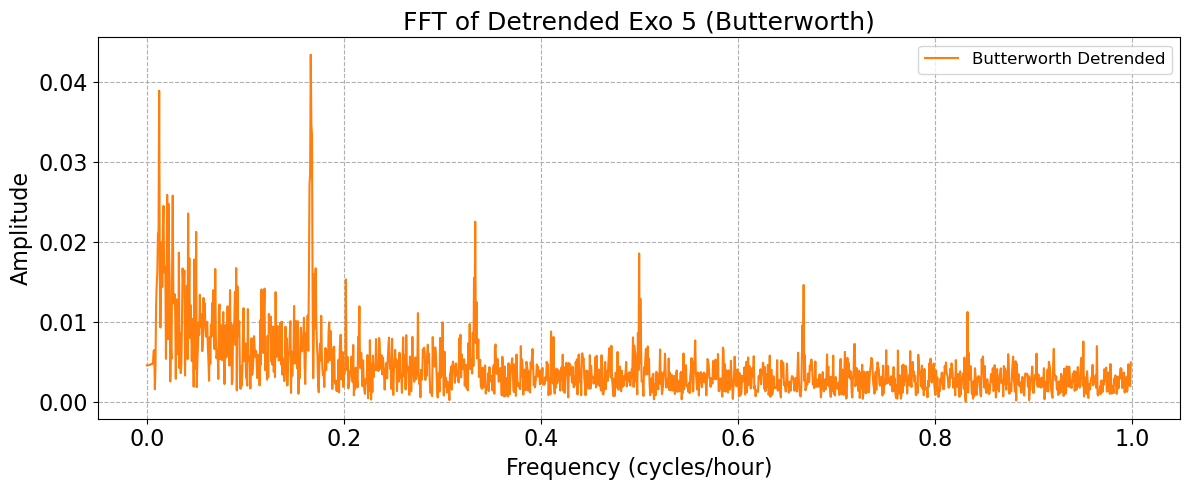

In [16]:
#Detrend FFTs from the above trends for examinations
#Seasonal
detrended_exo5 = decomp5.observed - decomp5.trend
detrended_exo5_clean = detrended_exo5.dropna()
N5 = len(detrended_exo5_clean)
dt = 0.5 
freq5 = fftfreq(N5, d=dt)
fft_vals5 = np.abs(fft(detrended_exo5_clean))[:N5//2] / N5

plt.figure(figsize=(10, 4))
plt.plot(freq5[:N5//2], fft_vals5, color='tab:orange')
plt.title("FFT of Detrended Light Curve – Exoplanet 5 - Seasonal",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Hann Window
hann_trend = np.convolve(exo5_clean, hann_kernel, mode='same')
detrended_hann = exo5_clean - hann_trend
N = len(exo5_clean)
freq = fftfreq(N, d=dt)
fft_hann = np.abs(fft(detrended_hann))[:N//2] / N
plt.figure(figsize=(12, 5))
plt.plot(freq[:N//2], fft_hann, label="Hann Detrended", color="tab:orange")
plt.title("FFT of Detrended Light Curve – Exoplanet 5 - Hann Window",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Low_Pass
detrended_butter = exo5_clean - trend_butter
fft_butter = np.abs(fft(detrended_butter))[:N//2] / N
plt.figure(figsize=(12, 5))
plt.plot(freq[:N//2], fft_butter, label="Butterworth Detrended", color="tab:Orange")
plt.title("FFT of Detrended Exo 5 (Butterworth)",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Hann Window is best

Estimated Transit Period: 6.01 hours


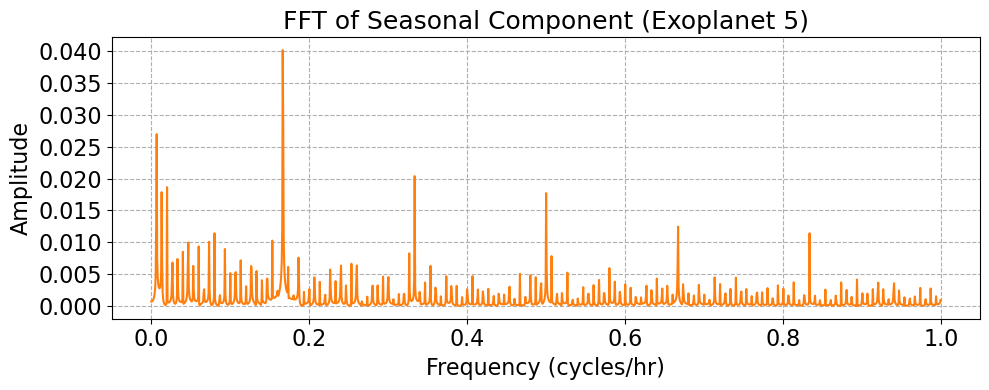

In [17]:
#Estimate Transit Period from Seasonal Component
AMPLITUDE_THRESHOLD = 0.025
seasonal = decomp5.seasonal
seasonal_fft = np.abs(fft(seasonal))[:N//2] / N
valid_range = seasonal_fft[1:]
if np.max(valid_range) > AMPLITUDE_THRESHOLD:
    peak_freq_idx = np.argmax(valid_range) + 1
    peak_freq = freq[peak_freq_idx]
    estimated_period_hours = 1 / peak_freq if peak_freq > 0.01 else np.nan
else:
    estimated_period_hours = np.nan

print(f"Estimated Transit Period: {estimated_period_hours:.2f} hours")

plt.figure(figsize=(10, 4))
plt.plot(freq[:N//2], seasonal_fft, color='tab:orange')
plt.title("FFT of Seasonal Component (Exoplanet 5)",fontsize=18)
plt.xlabel("Frequency (cycles/hr)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

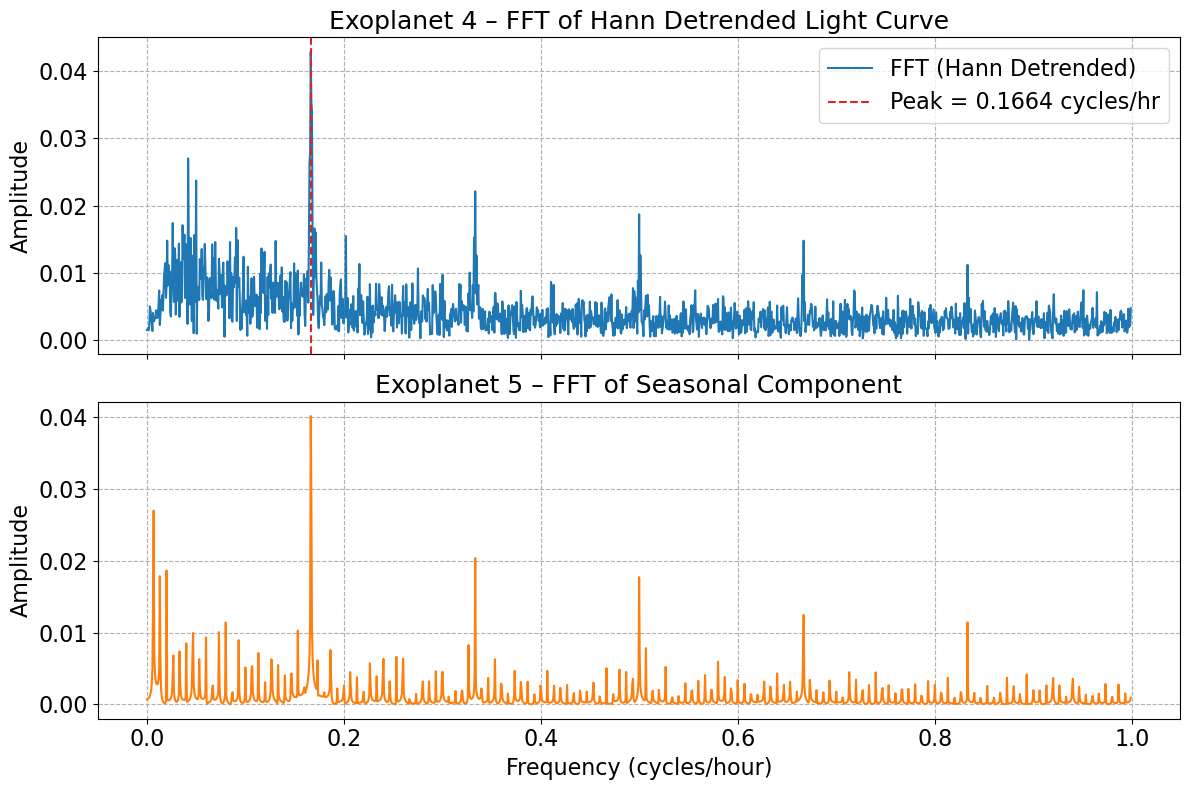

In [18]:
#Combination of plots for enhencing spacing of the report
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, tight_layout=True)
# Plot for Exoplanet 4 (Hann detrended)
axes[0].plot(freq_pos, fft_hann, label="FFT (Hann Detrended)", color='tab:blue')
axes[0].axvline(peak_freq, color='tab:red', linestyle='--', label=f"Peak = {peak_freq:.4f} cycles/hr")
axes[0].set_title("Exoplanet 4 – FFT of Hann Detrended Light Curve", fontsize=18)
axes[0].set_ylabel("Amplitude", fontsize=16)
axes[0].grid(True, linestyle='--')
axes[0].legend(fontsize=16)
axes[0].tick_params(labelsize=16)

# Plot for Exoplanet 5 (Seasonal)
axes[1].plot(freq[:N//2], seasonal_fft, label="FFT (Seasonal Component)", color='tab:orange')
axes[1].set_title("Exoplanet 5 – FFT of Seasonal Component", fontsize=18)
axes[1].set_xlabel("Frequency (cycles/hour)", fontsize=16)
axes[1].set_ylabel("Amplitude", fontsize=16)
axes[1].grid(True, linestyle='--')
axes[1].tick_params(labelsize=16)
plt.show()

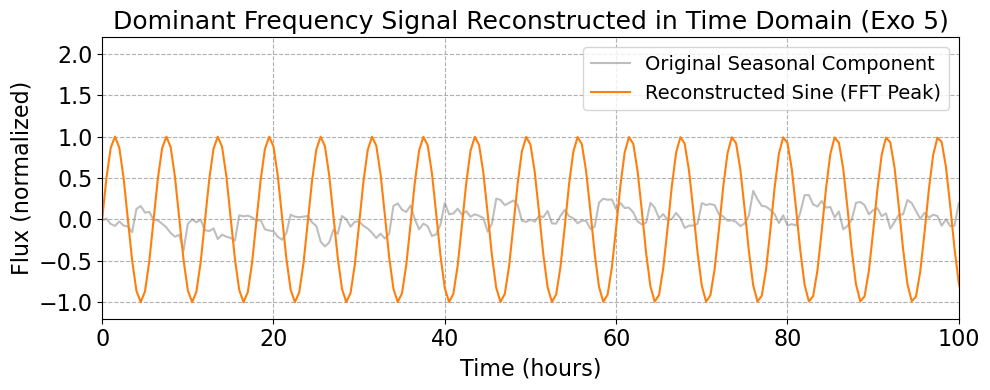

In [19]:
# Reconstruct a sine wave using the estimated period,
#In reinforcing our estimate above

time_steps = np.arange(N) * 0.5  # since dt = 0.5 hr
reconstructed_wave = np.sin(2 * np.pi * peak_freq * time_steps)

plt.figure(figsize=(10, 4))
plt.plot(time_steps, seasonal, label='Original Seasonal Component', alpha=0.5, color='tab:gray')
plt.plot(time_steps, reconstructed_wave, label='Reconstructed Sine (FFT Peak)', color='tab:orange')
plt.title("Dominant Frequency Signal Reconstructed in Time Domain (Exo 5)", fontsize=18)
plt.xlabel("Time (hours)", fontsize=16)
plt.ylabel("Flux (normalized)", fontsize=16)
plt.xlim(0,100)
plt.ylim(-1.2,2.2)
plt.legend(fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

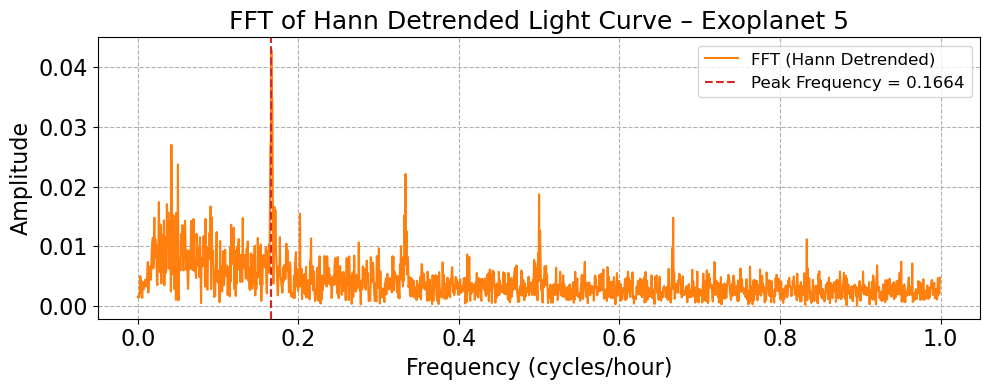

 Estimated Transit Period: 6.01 hours


In [20]:
#Attempt in estimation of the transit period from the Hann window detrended fft
#of the exo 5 data
peak_idx = np.argmax(fft_hann[1:]) + 1
freq_pos = freq[:N//2]
peak_freq = freq_pos[peak_idx]
estimated_period_hours = 1 / peak_freq if peak_freq > 0 else np.nan

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, fft_hann, label="FFT (Hann Detrended)", color='tab:orange')
plt.axvline(peak_freq, color='tab:red', linestyle='--', label=f"Peak Frequency = {peak_freq:.4f}")
plt.title("FFT of Hann Detrended Light Curve – Exoplanet 5",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print(f" Estimated Transit Period: {estimated_period_hours:.2f} hours")

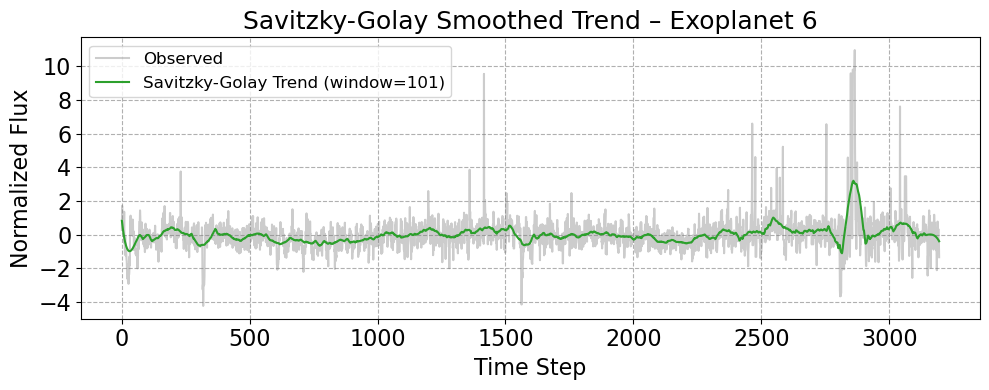

In [21]:
#Exo 6
#Savitzky-Golay Filter applied to see a trend 
#while smoothing out the sudden peaks in reducing noise
exo6 = exoplanet_curves_normalized[6]
exo6_series = pd.Series(exo6)
window_length = 101
poly_order = 3
trend_savgol = savgol_filter(exo6_series, window_length=window_length, polyorder=poly_order)

plt.figure(figsize=(10, 4))
plt.plot(exo6_series, label="Observed", alpha=0.4, color='gray')
plt.plot(trend_savgol, label=f"Savitzky-Golay Trend (window={window_length})", color='tab:green')
plt.title("Savitzky-Golay Smoothed Trend – Exoplanet 6",fontsize=18)
plt.xlabel("Time Step",fontsize=16)
plt.ylabel("Normalized Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

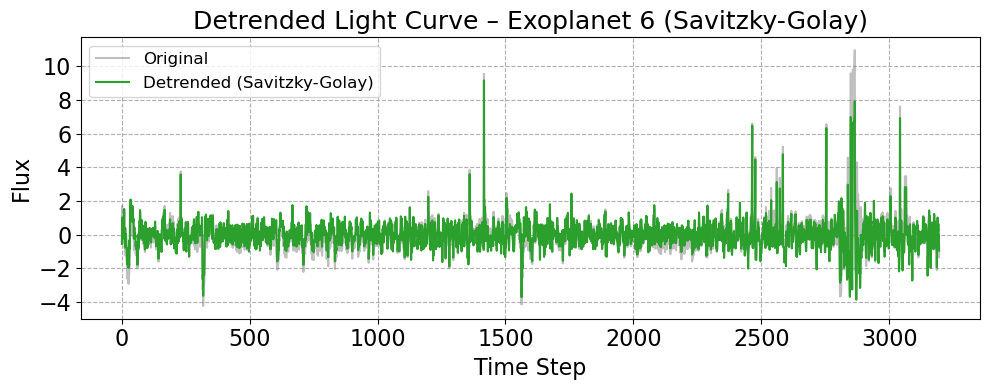

In [22]:
#Attempt to detrend for visual examinations
detrended_exo6_sg = exo6_series - trend_savgol
plt.figure(figsize=(10, 4))
plt.plot(exo6_series, label="Original", alpha=0.5, color='gray')
plt.plot(detrended_exo6_sg, label="Detrended (Savitzky-Golay)", color='tab:green')
plt.title("Detrended Light Curve – Exoplanet 6 (Savitzky-Golay)",fontsize=18)
plt.xlabel("Time Step",fontsize=16)
plt.ylabel("Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

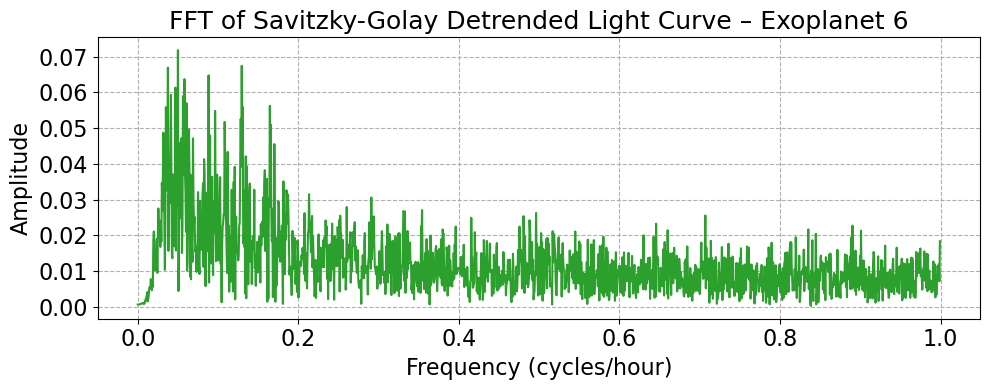

In [23]:
#PLotting out the FFT from Fouier analysis, in search for dominant frequency
N = len(detrended_exo6_sg)
dt = 0.5
freq = fftfreq(N, d=dt)
fft_vals_sg = np.abs(fft(detrended_exo6_sg))[:N//2] / N
freq_pos = freq[:N//2]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(freq_pos, fft_vals_sg, label="FFT of SG-Detrended Signal", color='tab:green')
plt.title("FFT of Savitzky-Golay Detrended Light Curve – Exoplanet 6",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


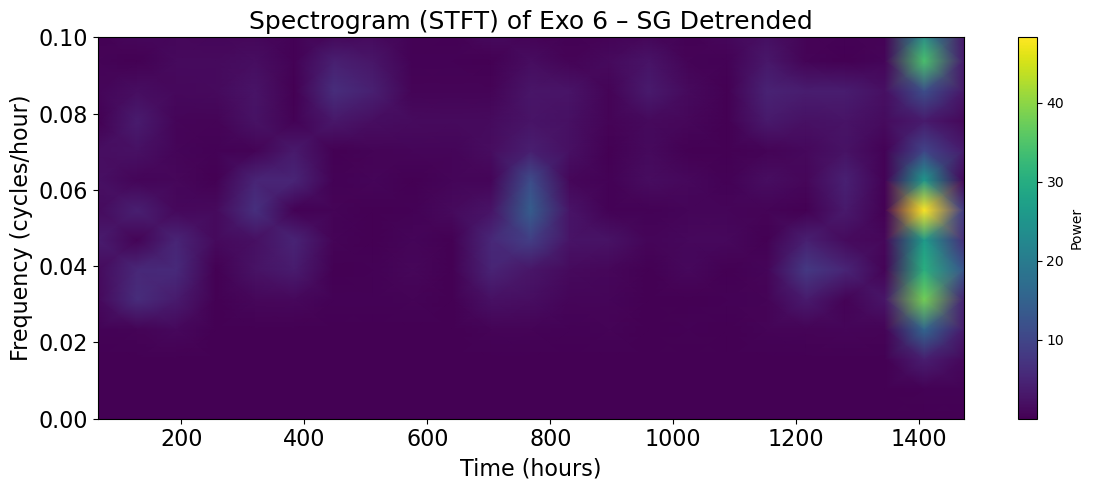

In [24]:
#Preforming the SFTF and plotting out the spectrogram, spotting a highlight
fs = 1 / 0.5
nperseg = 256
noverlap = nperseg // 2
f, t, Sxx = spectrogram(detrended_exo6_sg, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f, Sxx, shading='gouraud', cmap='viridis')
plt.title("Spectrogram (STFT) of Exo 6 – SG Detrended",fontsize=18)
plt.ylabel("Frequency (cycles/hour)",fontsize=16)
plt.xlabel("Time (hours)",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.colorbar(label="Power")
plt.ylim(0, 0.1)
plt.tight_layout()
plt.show()


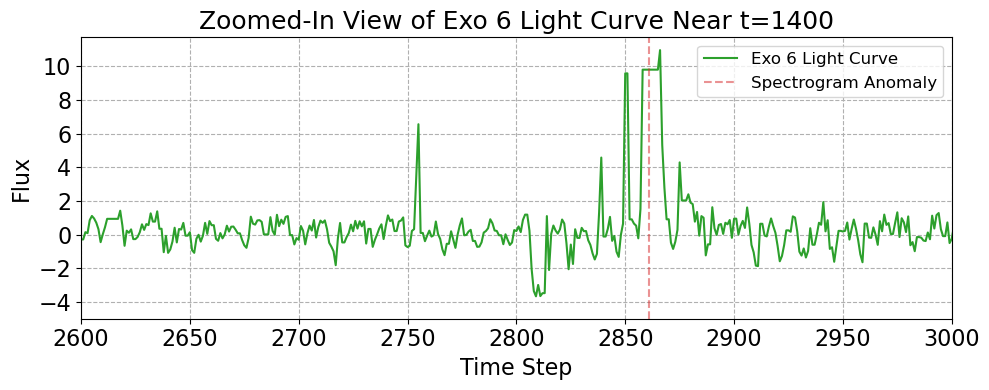

In [25]:
#Zooming in at the spectrogram suggested highlight time step
#On the Time domain plot
plt.figure(figsize=(10, 4))
plt.plot(exo6_series, label="Exo 6 Light Curve", color='tab:green')
plt.axvline(2861, color='tab:red', linestyle='--', label='Spectrogram Anomaly',alpha=0.5)
plt.xlim(2600, 3000)
plt.xlabel("Time Step",fontsize=16)
plt.ylabel("Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Zoomed-In View of Exo 6 Light Curve Near t=1400",fontsize=18)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()
#Likely: Stellar flare or outburst, short-lived, 
#high-energy event — generates power across many frequencies

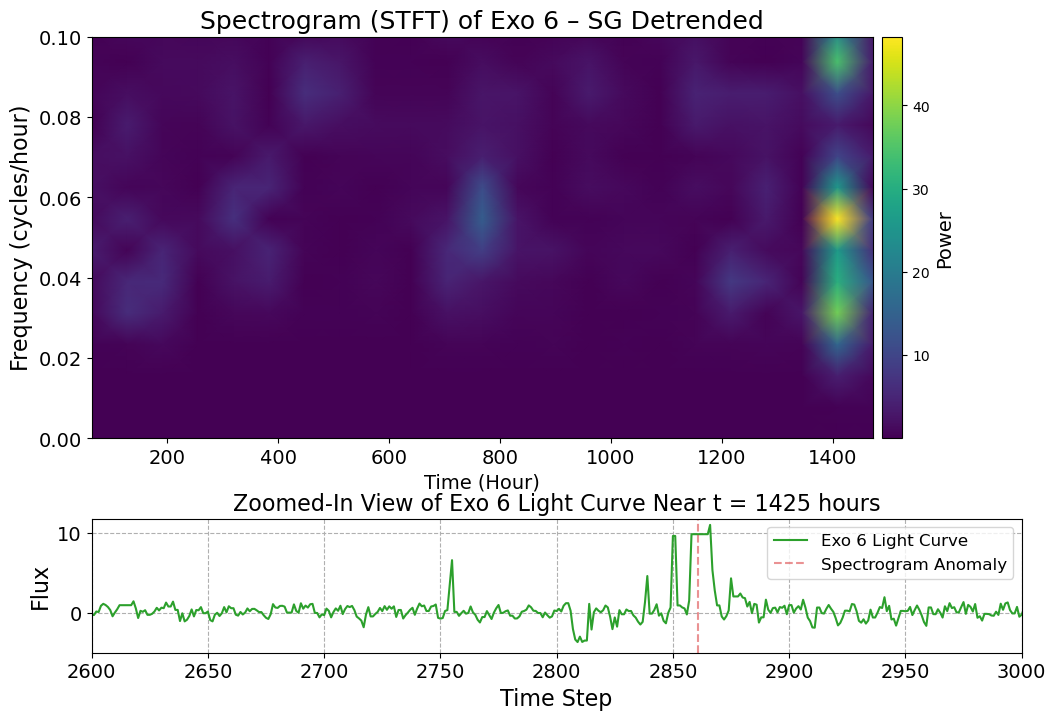

In [26]:
#Merging plots together for enhencing visuals of the report
fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.3})

im = axes[0].pcolormesh(t, f, Sxx, shading='gouraud', cmap='viridis')
axes[0].set_title("Spectrogram (STFT) of Exo 6 – SG Detrended", fontsize=18)
plt.xlabel("Time (hours)",fontsize=16)
axes[0].set_ylabel("Frequency (cycles/hour)", fontsize=16)
axes[0].set_xlabel("Time (Hour)", fontsize=14)
axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_ylim(0, 0.1)
axes[0].tick_params(axis='both', labelsize=14)
cbar = fig.colorbar(im, ax=axes[0], orientation='vertical', pad=0.01)
cbar.set_label("Power", fontsize=14)

axes[1].plot(exo6_series, label="Exo 6 Light Curve", color='tab:green')
axes[1].axvline(2861, color='tab:red', linestyle='--', label='Spectrogram Anomaly', alpha=0.5)
axes[1].set_xlim(2600, 3000)
axes[1].set_xlabel("Time Step", fontsize=16)
axes[1].set_ylabel("Flux", fontsize=16)
axes[1].set_title("Zoomed-In View of Exo 6 Light Curve Near t = 1425 hours", fontsize=16)
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--')
axes[1].tick_params(axis='both', labelsize=14)

plt.show()

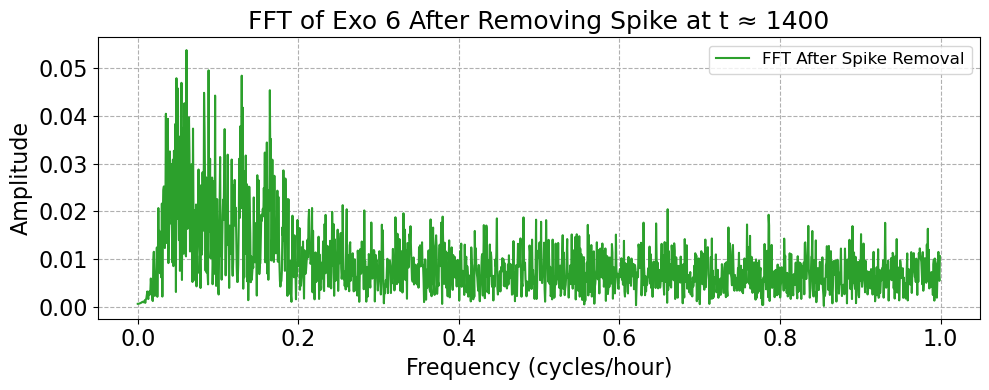

In [27]:
#outlier removal and re-run the FFT, in attempt to see a difference
#potenial supporting argument that was not mentioned in the report
exo6_cleaned = exo6_series.copy()
threshold = exo6_cleaned.mean() + 3 * exo6_cleaned.std()
spike_mask = exo6_cleaned > threshold
exo6_cleaned[spike_mask] = np.nan
exo6_cleaned_interp = exo6_cleaned.interpolate(method='linear')
trend_sg_cleaned = savgol_filter(exo6_cleaned_interp, window_length=101, polyorder=3)
detrended_cleaned = exo6_cleaned_interp - trend_sg_cleaned
N = len(detrended_cleaned)
freq = fftfreq(N, d=0.5)
fft_cleaned = np.abs(fft(detrended_cleaned))[:N//2] / N
freq_pos = freq[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, fft_cleaned, color='tab:green', label="FFT After Spike Removal")
plt.title("FFT of Exo 6 After Removing Spike at t ≈ 1400",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
#Out come: lacks a stable periodic signal, confirms the high-energy event

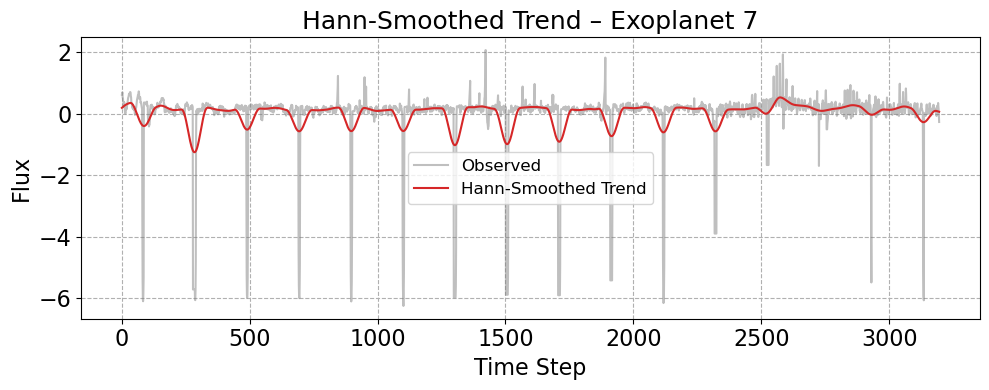

In [28]:
#Exo 7
# Exo 7 with Hann Smoothing, outputting the trend(Not usful in our context)
exo7 = exoplanet_curves_normalized[7]
exo7_series = pd.Series(exo7)
window_size = 101 
hann_kernel = np.hanning(window_size)
hann_kernel /= np.sum(hann_kernel)
exo7_trend = np.convolve(exo7_series, hann_kernel, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(exo7_series, label="Observed", alpha=0.5, color='gray')
plt.plot(exo7_trend, label="Hann-Smoothed Trend", color='tab:red')
plt.title("Hann-Smoothed Trend – Exoplanet 7",fontsize=18)
plt.xlabel("Time Step",fontsize=16)
plt.ylabel("Flux",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

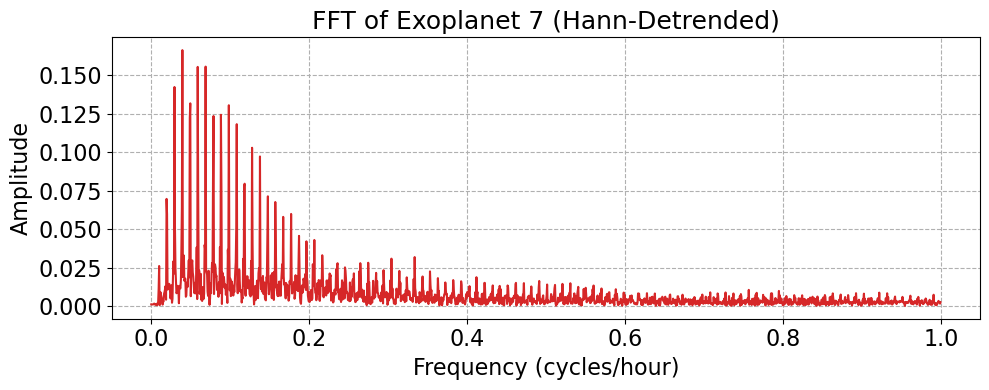

In [29]:
#Detrend and plot FFT
#The detrended FFT plot of Exo 7
detrended_exo7 = exo7_series - exo7_trend
N = len(detrended_exo7)
dt = 0.5
freq = fftfreq(N, d=dt)
fft_vals = np.abs(fft(detrended_exo7))[:N//2] / N
freq_pos = freq[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(freq_pos, fft_vals, label="FFT of Detrended Signal", color='tab:red')
plt.title("FFT of Exoplanet 7 (Hann-Detrended)",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


In [30]:
#Estimate Transit Period from above analysis
#Could be used as a supporting result
peak_index = np.argmax(fft_vals[1:]) + 1
peak_freq = freq_pos[peak_index]
estimated_period_hours = 1 / peak_freq if peak_freq != 0 else np.nan
print(f"Estimated Transit Period: {estimated_period_hours:.2f} hours")

Estimated Transit Period: 25.37 hours


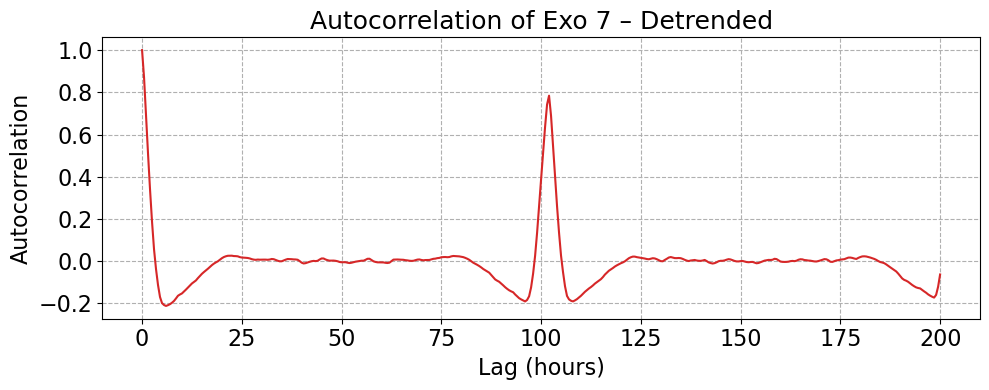

In [31]:
#Autocorrection applied as an alternative way of finging the peak in lag
from statsmodels.tsa.stattools import acf
lags = 400
acf_vals = acf(detrended_exo7, nlags=lags, fft=True)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(lags + 1) * dt, acf_vals, color='tab:red')
plt.title("Autocorrelation of Exo 7 – Detrended",fontsize=18)
plt.xlabel("Lag (hours)",fontsize=16)
plt.ylabel("Autocorrelation",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

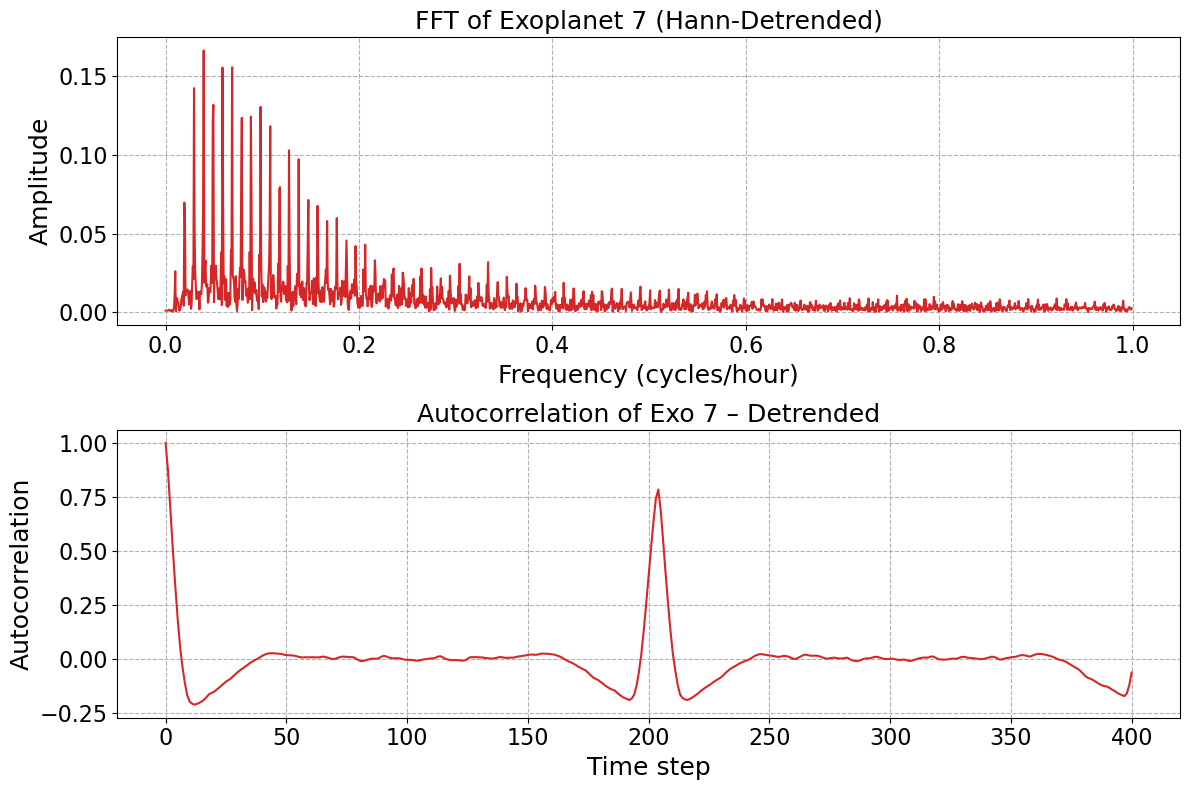

In [32]:
#Merging of above two plots to show comparision,
#With the FFT suggesting too short of a transit period
#and ACF giving the more reasonable output when compared to raw data visuals
N = len(detrended_exo7)
dt = 0.5
freq = fftfreq(N, d=dt)
freq_pos = freq[:N//2]
fft_vals = np.abs(fft(detrended_exo7))[:N//2] / N

lags = 400
acf_vals = acf(detrended_exo7, nlags=lags, fft=True)
lag_hours = np.arange(lags + 1) * dt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False, tight_layout=True)

axes[0].plot(freq_pos, fft_vals, label="FFT of Detrended Signal", color='tab:red')
axes[0].set_title("FFT of Exoplanet 7 (Hann-Detrended)", fontsize=18)
axes[0].set_xlabel("Frequency (cycles/hour)", fontsize=18)
axes[0].set_ylabel("Amplitude", fontsize=18)
axes[0].tick_params(labelsize=16)
axes[0].grid(True, linestyle='--')

axes[1].plot(lag_hours*2, acf_vals, color='tab:red')
axes[1].set_title("Autocorrelation of Exo 7 – Detrended", fontsize=18)
axes[1].set_xlabel("Time step", fontsize=18)
axes[1].set_ylabel("Autocorrelation", fontsize=18)
axes[1].tick_params(labelsize=16)
axes[1].grid(True, linestyle='--')

plt.show()


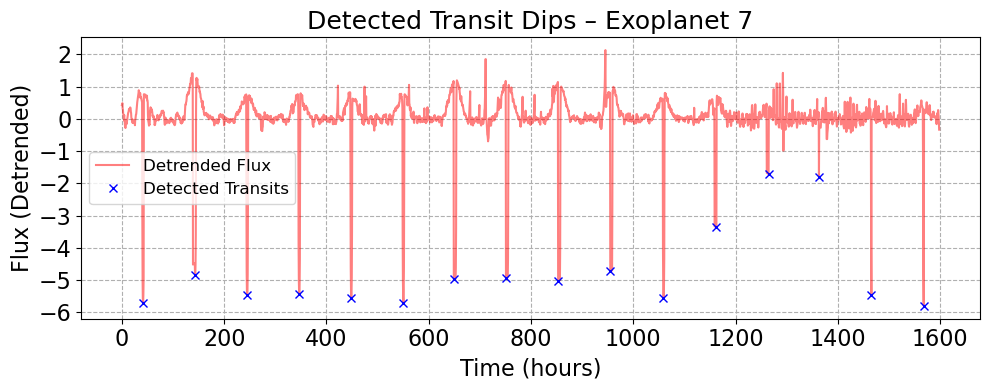

Estimated Transit Period (peak spacing): 101.77 hours


In [33]:
#Find peaks to get period time, in supporting our assumption by visual in the
#raw flux data plot
signal_inverted = -detrended_exo7
peaks, properties = find_peaks(
    signal_inverted,
    prominence=2,
    distance=30
)

time = np.arange(len(detrended_exo7)) * 0.5
peak_times = time[peaks]

plt.figure(figsize=(10, 4))
plt.plot(time, detrended_exo7, label="Detrended Flux",color ='red', alpha=0.5)
plt.plot(time[peaks], detrended_exo7[peaks], 'bx', label="Detected Transits")
plt.title("Detected Transit Dips – Exoplanet 7",fontsize=18)
plt.xlabel("Time (hours)",fontsize=16)
plt.ylabel("Flux (Detrended)",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

peak_deltas = np.diff(peak_times)
estimated_period_peaks = np.mean(peak_deltas)
print(f"Estimated Transit Period (peak spacing): {estimated_period_peaks:.2f} hours")


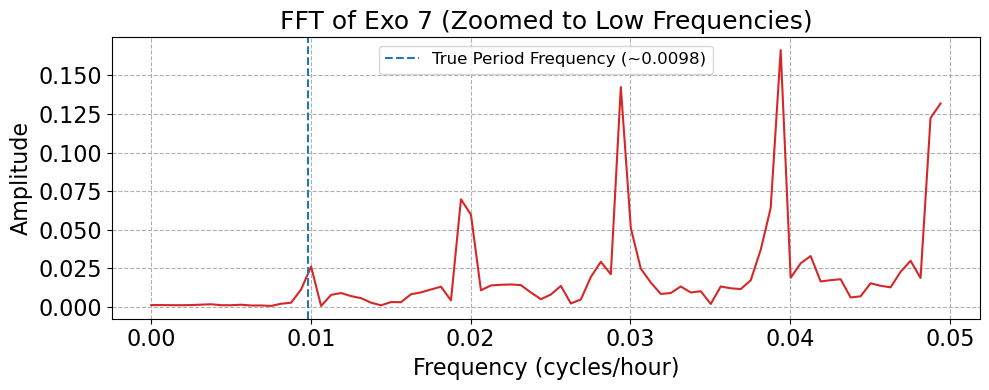

 FFT-corrected Period Estimate: 106.57 hours


In [34]:
# Further verify our theroy by going back to the Fouier analysis
# Looking at low frequencies only, seeing a different Fouier apporach needed
# for exo 7
 
zoom_range = freq_pos < 0.05

plt.figure(figsize=(10, 4))
plt.plot(freq_pos[zoom_range], fft_vals[zoom_range], color='tab:red')
plt.axvline(1 / 101.77, color='tab:blue', linestyle='--', label='True Period Frequency (~0.0098)')
plt.title("FFT of Exo 7 (Zoomed to Low Frequencies)",fontsize=18)
plt.xlabel("Frequency (cycles/hour)",fontsize=16)
plt.ylabel("Amplitude",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

low_freq_range = (freq_pos > 0.005) & (freq_pos < 0.01)
low_freqs = freq_pos[low_freq_range]
low_fft_vals = fft_vals[low_freq_range]

true_peak_index = np.argmax(low_fft_vals)
true_freq = low_freqs[true_peak_index]

true_period_fft = 1 / true_freq

print(f" FFT-corrected Period Estimate: {true_period_fft:.2f} hours")


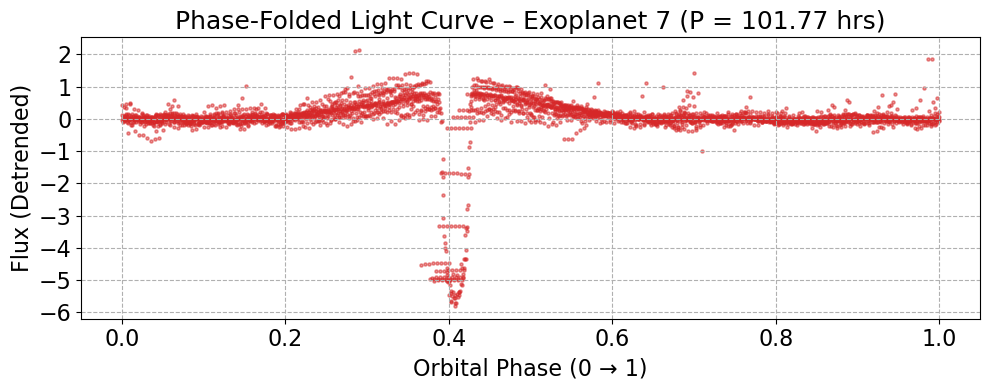

In [35]:
#Phase-Folding the Light Curve of exo 7 to further prove our correct assumption
period = 101.77
time = np.arange(len(detrended_exo7)) * 0.5
phase = (time % period) / period
plt.figure(figsize=(10, 4))
plt.scatter(phase, detrended_exo7, s=5, alpha=0.5, color='tab:red')
plt.title("Phase-Folded Light Curve – Exoplanet 7 (P = 101.77 hrs)",fontsize=18)
plt.xlabel("Orbital Phase (0 → 1)",fontsize=16)
plt.ylabel("Flux (Detrended)",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()
